In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as ss
import seaborn as sns
import missingno as msno
import plotly.express as px

%matplotlib inline 
%config InlineBackend.figure_format = 'retina'

df = pd.read_csv("../data/apartments_for_rent_classified_100K.csv", sep=';', encoding="cp1250")
#df.head(1)
# usuwamy linie mające puste pole cityname
df = df.dropna(subset=['cityname'])
# znajdź indeksy wierszy do usunięcia dla ilości = 0 i =null
idx_to_drop = df[((df["bedrooms"] == 0) | (df["bedrooms"].isna()))& (df["square_feet"] >= 500)].index

# usuń te wiersze
df = df.drop(idx_to_drop)
# df.to_csv("plik_wynik.csv", index=False, sep=";")   # to dla sprawdzenia jak poszło ....  ;)

# dla małych pomieszczeń, które pozostały z wartością null zmień ja na = 0
df["bedrooms"] = df["bedrooms"].fillna(0)
df.isna().sum() 

# Zgodnie z powyższą sugestią dopisuję zmianę null na "None"
df["pets_allowed"] = df["pets_allowed"].fillna("None")

# Zgodnie ze wstępną analizą w analiza.ipynb usuwamy linię bez ceny
df = df.dropna(subset=["price"])

#zamiana pozycji jednostkowej Cats,Dogs,None na Cats,Dogs
df['pets_allowed'] = df['pets_allowed'].str.replace("Cats,Dogs,None", "Cats,Dogs", regex=False)

C:\Users\Grażyna\AppData\Local\Temp\ipykernel_10116\994894044.py:12: DtypeWarning: Columns (0: address) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/apartments_for_rent_classified_100K.csv", sep=';', encoding="cp1250")


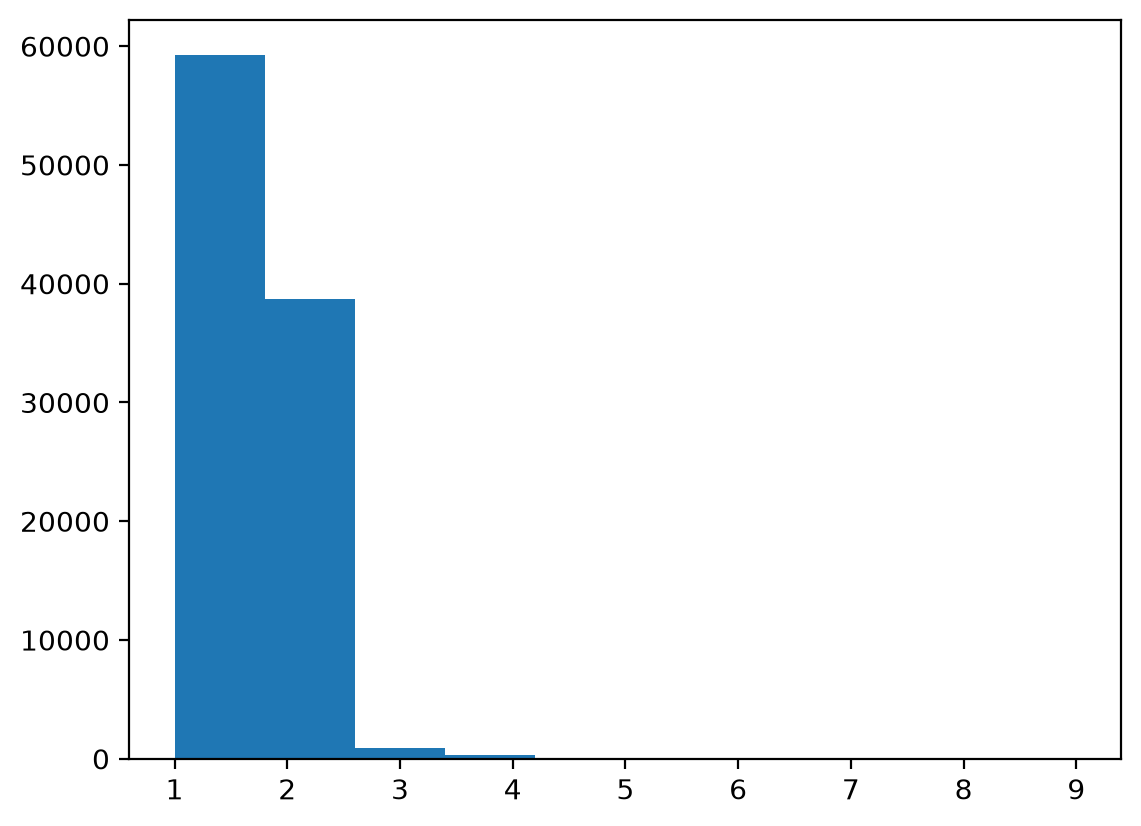

In [3]:
p = plt.hist(df['bathrooms'])

Text(0, 0.5, 'Liczebność')

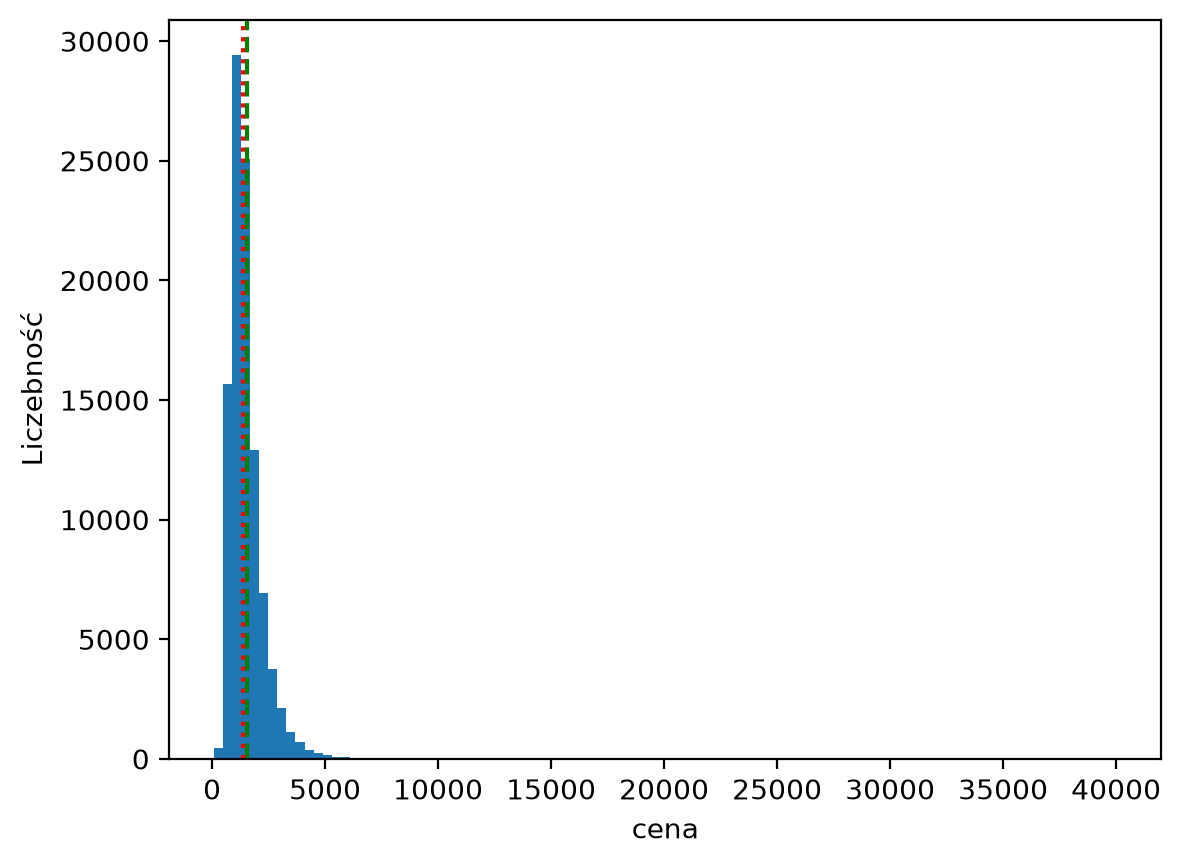

In [4]:
p = plt.hist(df['price'], bins = 100)
plt.axvline(df['price'].mean(), linestyle = "dashed", color = "green");
plt.axvline(df['price'].median(), linestyle = "dotted", color = "red");
plt.xlabel('cena')
plt.ylabel('Liczebność')



In [5]:
fig = px.histogram(df, x="price",color="square_feet")
fig.show()

Jeśli color="square_feet" ma dużo unikalnych wartości, Plotly tworzy bardzo dużo serii i histogram staje się nieczytelny.
Najpierw podziel square_feet na przedziały (bins), a potem koloruj tymi przedziałami:

In [6]:
# przykładowe przedziały powierzchni
df_f1 = df[df["price"] < 1500]
df_f1["sqft_bin"] = pd.cut(
    df_f1["square_feet"],
    bins=[0, 500, 700, 900, 1000, float("inf")],
    labels=["0-500", "500-700", "700-900", "900-1000","1000-1500"]
)

fig = px.histogram(
    df_f1,
    x="price",
    color="sqft_bin",
    nbins=20
)

fig.show()


In [7]:
# przykładowe przedziały powierzchni
df_f2 = df[(df["price"] > 1500) & (df["price"] < 6000)]
df_f2["sqft_bin"] = pd.cut(
    df_f2["square_feet"],
    bins=[1500, 2000, 3000, 4000,  float("inf")],
    labels=["1500-2000", "2000-3000", "3000-4000", "4000-6000"]
)

fig = px.histogram(
    df_f2,
    x="price",
    color="sqft_bin",
    nbins=30
)

fig.show()


In [8]:
df_f3 = df[(df["price"] > 6000) ]
df_f3["sqft_bin"] = pd.cut(
    df_f3["square_feet"],
    bins=[6000, 10000, 20000, 30000,  float("inf")],
    labels=["6000-10000", "10000-20000", "20000-30000", "30000+"]
)

fig = px.histogram(
    df_f3,
    x="price",
    facet_row="sqft_bin",
    nbins=30
)

fig.show()

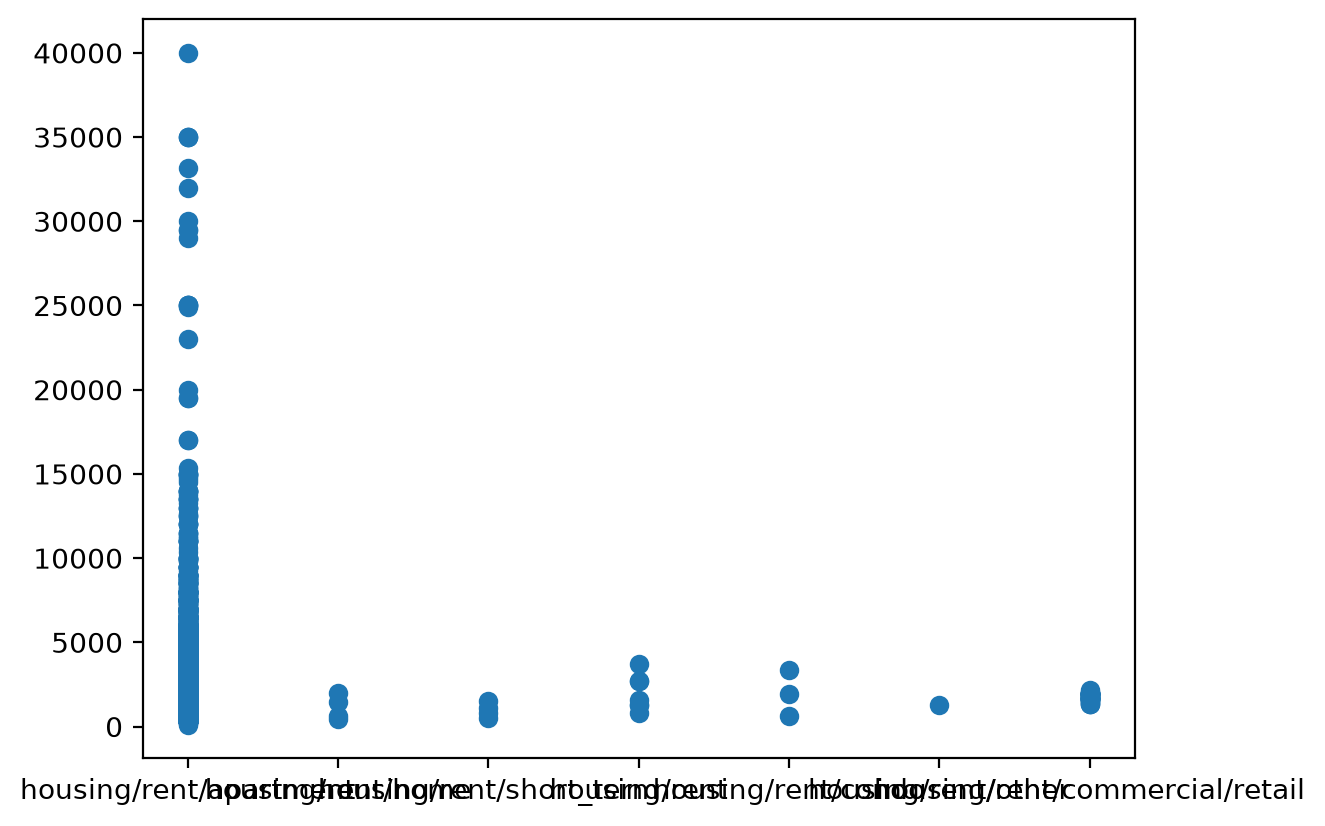

In [10]:
p = plt.scatter(df["category"], df['price'])

In [11]:
# przykładowe przedziały powierzchni
df_f2 = df[(df["price"] > 1500) & (df["price"] < 6000)]
df_f2["sqft_bin"] = pd.cut(
    df_f2["square_feet"],
    bins=[1500, 2000, 3000, 4000,  float("inf")],
    labels=["1500-2000", "2000-3000", "3000-4000", "4000-6000"]
)

fig = px.scatter(
    df_f2,
    x="price",
    y="state",
    color="sqft_bin",
    color_discrete_map={
        "1500-2000": "green",
        "2000-3000": "yellow",
        "3000-4000": "orange",
        "4000-6000": "red"
    }
)

fig.show()


In [12]:
# przykładowe przedziały powierzchni
df_f2 = df[(df["price"] > 1500) & (df["price"] < 6000)]
df_f2["price"] = pd.cut(
    df_f2["price"],
    bins=[700, 1000, 2000, 3000, 5000, float("inf")],
    labels=["700-1000", "1000-2000", "2000-3000", "3000-5000", "5000+"]
)

fig = px.scatter(
    df_f2,
    x="square_feet",
    y="state",
    color="price",
    color_discrete_map={
        "700-1000": "green",
        "1000-2000": "yellow",
        "2000-3000": "orange",
        "3000-5000": "red",
        "5000+"    : "purple"
    },
    size="bedrooms"
)

fig.show()